Title: PSL_cluster_new.ipynb

Purpose: Make a clustering of large scale weather patterns

Author: Onno Nennecke on 03.06.2025 Modified: 26.03.2026

Input data: 

- PSL Anomaly Data
    - This file lies here: /climca/people/onennecke/model_output/psl_anomaly/not_bc/
- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

- LEE Tables: LEE_dat_14_fut.csv, LEE_dat_7_fut.csv, LEE_dat_fut.csv, LEE_dat_14_selection_fut.csv, LEE_dat_7_selection_fut.csv, LEE_vl_fut.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:

- kmeans scores: psl_kmeans_score_diff_k.csv
    - This file lies here: /home/onennecke/psl_clustering/psl_kmeans_score_diff_k.csv
- Kmeans score Plot: PSL_cluster_elbow_silhouette
    - This file lies here: /home/onennecke/Code/Figures/
- centroids and labels
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc.npz'
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc_2.npz


### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
import cftime
# import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist



In [10]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

## Select only relevant timesteps for the clustering!!

### Select relevant timesteps

In [3]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc'

# Read the PSL anomaly data
files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
ts_datasets['ESM_run'] = ts_datasets['ESM_run'].str.replace('CESM2_LE_LE2', 'CESM2_LE2', regex=False)
ts_datasets

# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_dat = LEE_dat[LEE_dat['date_start'].str[5:7] != '04']

# Filter ts_datasets to only include samples that match the date_start in LEE_dat
ts_datasets_filtered = ts_datasets.copy()

date_map = (
    LEE_dat.groupby("ESM_run")["date_start"]
    .apply(list)
    .to_dict()
)
ts_datasets_filtered = ts_datasets.copy()
mask = xr.zeros_like(ts_datasets_filtered.time, dtype=bool)

for esm, dates in date_map.items():
    dates_formatted = [
        cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
        for date in dates
    ]

    mask = mask | (
        (ts_datasets_filtered.ESM_run == esm) &
        (ts_datasets_filtered.time.isin(dates_formatted))
    )

ts_datasets_filtered = ts_datasets_filtered.where(mask, drop=True)

psl = ts_datasets_filtered['psl']

# Stack lat/lon into a single "space" dimension to prepare for PCA and clustering
psl_stacked = psl.stack(sample=("time", "ESM_run"))
# remove samples that are fully NaN
psl_stacked = psl_stacked.dropna(dim="sample", how="all")
psl_2d = psl_stacked.stack(space=("lat", "lon"))
X = psl_2d.values

weights = np.repeat(
    np.sqrt(np.cos(np.deg2rad(psl.lat.values))),
    psl.sizes["lon"]
)
X_weighted = X * weights[np.newaxis, :]

# PCA to reduce dimensionality
pca = PCA(n_components=0.90, svd_solver='full')  # keep 90% variance
X_pca = pca.fit_transform(X_weighted)  # shape: (n_times, n_eofs)
# print(pca.n_components_)

# Calculate KMeans with optimal k
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# 3. Run KMeans 
kmeans.fit(X_pca)  # fit in EOF space
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids_pca = kmeans.cluster_centers_  # shape (k, n_eofs)
# 4.1 Convert centroids back to original space
centroids = pca.inverse_transform(centroids_pca)  # shape (k, n_lat * n_lon)

# 5. Reshape centroids to lat/lon grid
centroids_reshaped = centroids.reshape(k_opt, psl.sizes['lat'], psl.sizes['lon'])  # shape (k, n_lat, n_lon)

# Count occurrences of each cluster
unique, counts = np.unique(labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print('Original cluster counts: ', cluster_counts)

# Save centroids and labels to a folder
# output_dir = '/home/onennecke/psl_clustering/clustering_results_nbc.npz'
# np.savez(output_dir, centroids_reshaped=centroids_reshaped, labels=labels)
# data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
# labels = data['labels']
# centroids_reshaped = data['centroids_reshaped']


# Now we check if we can assign the data to the new centroids and see if we get the same cluster counts as before. We will use the original data (not PCA-reduced) for this.

# stack lat/lon
psl_flat = psl.stack(space=("lat", "lon"))
# 2) Transpose so space is LAST
psl_flat = psl_flat.transpose("ESM_run", "time", "space")

# 3) Stack sample dimension
X_new = psl_flat.stack(sample=("ESM_run", "time"))

# 4) Make sure sample is first
X_new_np = X_new.transpose("sample", "space")

# Mask for valid samples (no NaN in any spatial point)
mask_valid = ~np.isnan(X_new_np).any(axis=1).compute()

# ------
# Transform your new data to the weighted PCA space
X_new_weighted = X_new_np * weights[np.newaxis, :]
X_new_pca = pca.transform(X_new_weighted[mask_valid])

# Assign labels using the PCA-space centroids
new_labels_valid = np.argmin(cdist(X_new_pca, centroids_pca), axis=1)
# -------


# # reshape centroids
# centroids_flat = centroids_reshaped.reshape(centroids_reshaped.shape[0], -1)

# # Compute distances only for valid samples
# X_new_np_valid = X_new_np[mask_valid]
# distances = cdist(X_new_np_valid, centroids_flat)
# new_labels_valid = np.argmin(distances, axis=1)

# Initialize labels array with -1 (or np.nan) for all samples
new_labels = np.full(X_new_np.shape[0], np.nan, dtype=float)
new_labels[mask_valid] = new_labels_valid

cluster_da = xr.DataArray(
    new_labels,
    coords={"sample": X_new.sample},
    dims=["sample"]
)

cluster_da = cluster_da.unstack("sample")
cluster_da

values, counts = np.unique(
    cluster_da.values[~np.isnan(cluster_da.values)],
    return_counts=True
)

print("Reassigned cluster counts: ", dict(zip(values, counts)))

Original cluster counts:  {np.int32(0): np.int64(9887), np.int32(1): np.int64(7284), np.int32(2): np.int64(7842), np.int32(3): np.int64(10204)}
Reassigned cluster counts:  {np.float64(0.0): np.int64(9887), np.float64(1.0): np.int64(7284), np.float64(2.0): np.int64(7842), np.float64(3.0): np.int64(10204)}


In [6]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc'

# Read the PSL anomaly data
files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
ts_datasets['ESM_run'] = ts_datasets['ESM_run'].str.replace('CESM2_LE_LE2', 'CESM2_LE2', regex=False)
ts_datasets

# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_dat = LEE_dat[LEE_dat['date_start'].str[5:7] != '04']

# Filter ts_datasets to only include samples that match the date_start in LEE_dat
ts_datasets_filtered = ts_datasets.copy()

date_map = (
    LEE_dat.groupby("ESM_run")["date_start"]
    .apply(list)
    .to_dict()
)
ts_datasets_filtered = ts_datasets.copy()
mask = xr.zeros_like(ts_datasets_filtered.time, dtype=bool)

for esm, dates in date_map.items():
    dates_formatted = [
        cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
        for date in dates
    ]

    mask = mask | (
        (ts_datasets_filtered.ESM_run == esm) &
        (ts_datasets_filtered.time.isin(dates_formatted))
    )

ts_datasets_filtered = ts_datasets_filtered.where(mask, drop=True)

psl = ts_datasets_filtered['psl']

# Stack lat/lon into a single "space" dimension to prepare for PCA and clustering
psl_stacked = psl.stack(sample=("time", "ESM_run"))
# remove samples that are fully NaN
psl_stacked = psl_stacked.dropna(dim="sample", how="all")
psl_2d = psl_stacked.stack(space=("lat", "lon"))
X = psl_2d.values

weights = np.repeat(
    np.sqrt(np.cos(np.deg2rad(psl.lat.values))),
    psl.sizes["lon"]
)
X_weighted = X * weights[np.newaxis, :]

# PCA to reduce dimensionality
pca = PCA(n_components=0.90, svd_solver='full')  # keep 90% variance
X_pca = pca.fit_transform(X_weighted)  # shape: (n_times, n_eofs)
# print(pca.n_components_)

# Calculate KMeans with optimal k
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# 3. Run KMeans 
kmeans.fit(X_pca)  # fit in EOF space
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids_pca = kmeans.cluster_centers_  # shape (k, n_eofs)

# ----------
# 1. Inverse transform centroids from PCA space to weighted original space
centroids_weighted = pca.inverse_transform(centroids_pca)  # shape: (k, n_lat * n_lon)

# 2. Remove the weighting from the centroids
#    weights is a 1D array of length n_lat * n_lon (or n_lat, repeated for lon)
#    You need to divide each centroid by the weights
centroids_unweighted = centroids_weighted / weights[np.newaxis, :]

# 3. Reshape to lat/lon grid
centroids_reshaped = centroids_unweighted.reshape(k_opt, psl.sizes['lat'], psl.sizes['lon'])

# 4. Flatten for distance calculation
centroids_flat = centroids_reshaped.reshape(k_opt, -1)

# ----------


# # 4.1 Convert centroids back to original space
# centroids = pca.inverse_transform(centroids_pca)  # shape (k, n_lat * n_lon)

# # 5. Reshape centroids to lat/lon grid
# centroids_reshaped = centroids.reshape(k_opt, psl.sizes['lat'], psl.sizes['lon'])  # shape (k, n_lat, n_lon)

# Count occurrences of each cluster
unique, counts = np.unique(labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print('Original cluster counts: ', cluster_counts)

# Save centroids and labels to a folder
# output_dir = '/home/onennecke/psl_clustering/clustering_results_nbc.npz'
# np.savez(output_dir, centroids_reshaped=centroids_reshaped, labels=labels)
# data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
# labels = data['labels']
# centroids_reshaped = data['centroids_reshaped']


# Now we check if we can assign the data to the new centroids and see if we get the same cluster counts as before. We will use the original data (not PCA-reduced) for this.

# stack lat/lon
psl_flat = psl.stack(space=("lat", "lon"))
# 2) Transpose so space is LAST
psl_flat = psl_flat.transpose("ESM_run", "time", "space")

# 3) Stack sample dimension
X_new = psl_flat.stack(sample=("ESM_run", "time"))

# 4) Make sure sample is first
X_new_np = X_new.transpose("sample", "space")

# Mask for valid samples (no NaN in any spatial point)
mask_valid = ~np.isnan(X_new_np).any(axis=1).compute()

# reshape centroids
# centroids_flat = centroids_reshaped.reshape(centroids_reshaped.shape[0], -1)

# Compute distances only for valid samples
X_new_np_valid = X_new_np[mask_valid]

distances = cdist(X_new_np_valid, centroids_flat)
new_labels_valid = np.argmin(distances, axis=1)

# Initialize labels array with -1 (or np.nan) for all samples
new_labels = np.full(X_new_np.shape[0], np.nan, dtype=float)
new_labels[mask_valid] = new_labels_valid

cluster_da = xr.DataArray(
    new_labels,
    coords={"sample": X_new.sample},
    dims=["sample"]
)

cluster_da = cluster_da.unstack("sample")
cluster_da

values, counts = np.unique(
    cluster_da.values[~np.isnan(cluster_da.values)],
    return_counts=True
)

print("Reassigned cluster counts: ", dict(zip(values, counts)))

Original cluster counts:  {np.int32(0): np.int64(9887), np.int32(1): np.int64(7284), np.int32(2): np.int64(7842), np.int32(3): np.int64(10204)}
Reassigned cluster counts:  {np.float64(0.0): np.int64(9623), np.float64(1.0): np.int64(7177), np.float64(2.0): np.int64(8056), np.float64(3.0): np.int64(10361)}


Explained variance ratio per component: [0.42340541 0.16913314 0.13156233 0.08248987 0.05609696 0.03637107
 0.02187663] sdf
Cumulative explained variance: [0.42340541 0.59253855 0.72410088 0.80659075 0.86268771 0.89905878
 0.92093541]


In [15]:
X_new_np_valid.shape

(35217, 2000)

In [13]:
X.shape

(35217, 2000)

In [8]:
centroids_unweighted

array([[-253.33611619, -252.47996141, -251.04169572, ...,  841.37281933,
         819.72623194,  796.76237534],
       [ -85.62207159,  -95.50939024, -106.70286611, ...,  488.79649827,
         482.73867963,  477.39310486],
       [-459.30558377, -463.46594764, -467.30562411, ..., 1077.30547115,
        1050.02029247, 1022.54607581],
       [  73.2921231 ,   66.6406403 ,   59.01151465, ...,  822.66103658,
         828.64736722,  833.56693038]])

/tmp/ipykernel_76283/3346614849.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


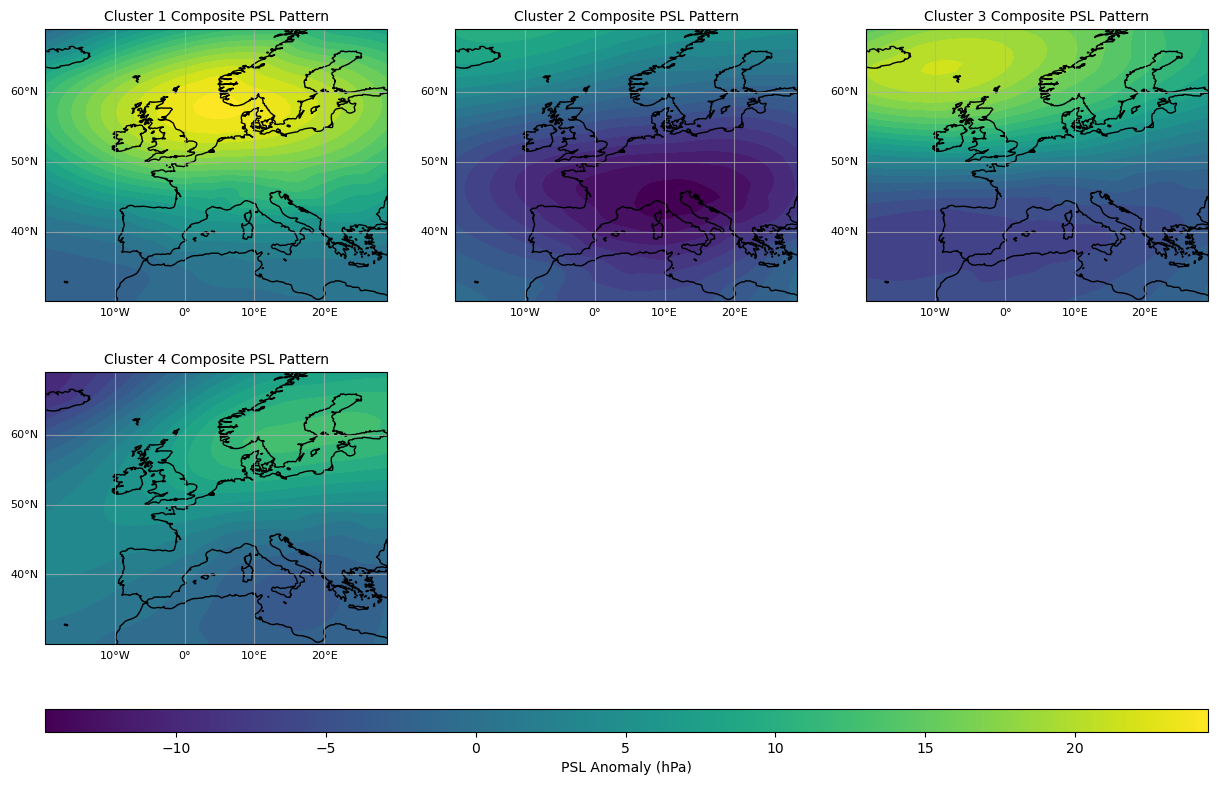

In [11]:
# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(centroids_reshaped / 100.0)
vmax = np.nanmax(centroids_reshaped / 100.0)

# 2) Decide on subplot grid
ncols = 3
k_opt = 4
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(centroids_reshaped[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree(), cmap='viridis')
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()


/tmp/ipykernel_2151361/3346614849.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


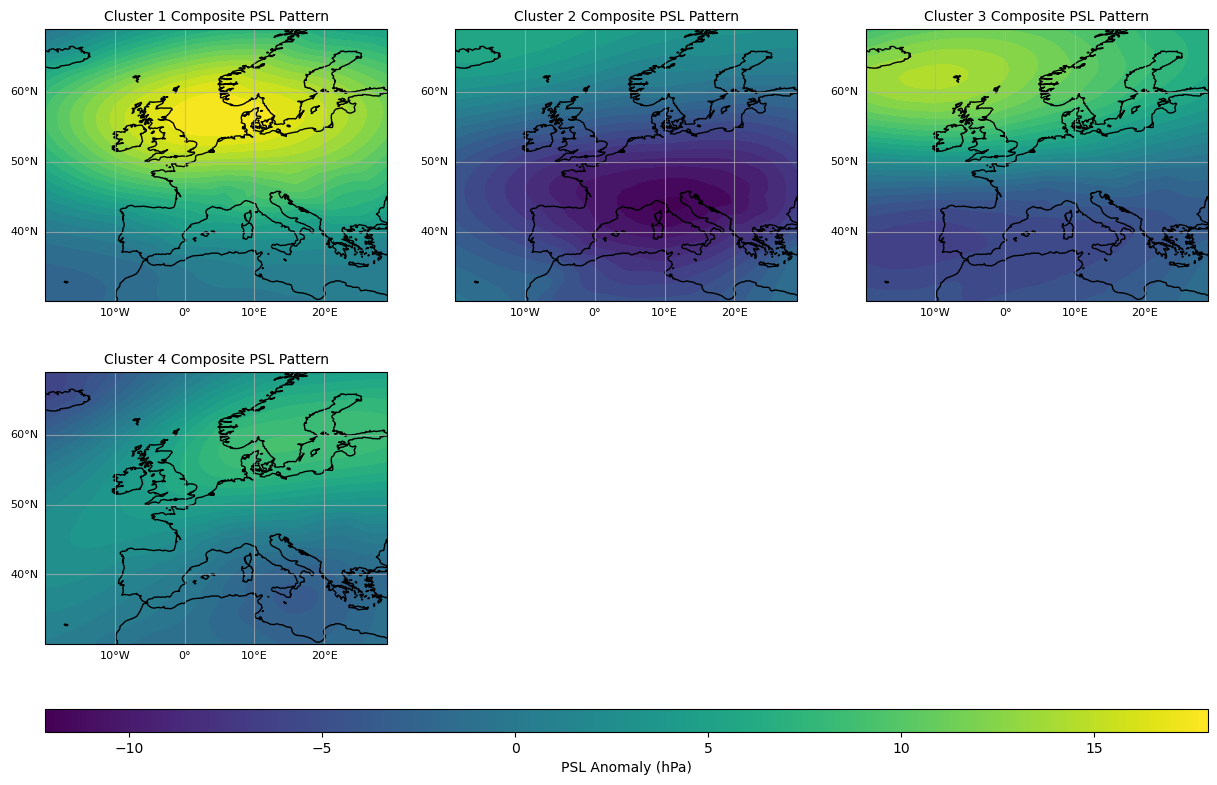

In [20]:
# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(centroids_reshaped / 100.0)
vmax = np.nanmax(centroids_reshaped / 100.0)

# 2) Decide on subplot grid
ncols = 3
k_opt = 4
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(centroids_reshaped[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree(), cmap='viridis')
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()


(193, 1523, 40, 50)
(4, 40, 50)
(193, 1523, 2000)
(293939, 2000)
(4, 2000)


<xarray.DataArray (ESM_run: 193, time: 1523)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [ 2.,  2.,  2., ..., nan,  3., nan],
       [nan, nan, nan, ...,  3., nan, nan]])
Coordinates:
  * ESM_run  (ESM_run) object 2kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i...
  * time     (time) object 12kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00

{np.float64(0.0): np.int64(12534), np.float64(1.0): np.int64(6623), np.float64(2.0): np.int64(8866), np.float64(3.0): np.int64(7194)}


In [21]:
values, counts = np.unique(
    labels,
    return_counts=True
)

print(dict(zip(values, counts)))

{np.int32(0): np.int64(9887), np.int32(1): np.int64(7284), np.int32(2): np.int64(7842), np.int32(3): np.int64(10204)}


In [23]:
labels.shape

(35217,)

In [24]:
new_labels.shape

(293939,)

##### Look how the clusters are seasonaly distributed

In [21]:
ts_datasets_filtered.sizes['ESM_run']
len(ts_datasets_filtered['ESM'])

1523

In [22]:
print(len(ts_datasets_filtered['ESM'].values))
print(len(ts_datasets_filtered['ESM'].values[0]))

1523
193


In [44]:
1523 * 193

293939

In [51]:
ts_datasets_filtered

<xarray.Dataset> Size: 2GB
Dimensions:    (ESM_run: 193, time: 1523, lat: 40, lon: 50)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        (time) int64 12kB dask.array<chunksize=(1523,), meta=np.ndarray>
    gridtype   (time) <U6 37kB dask.array<chunksize=(1523,), meta=np.ndarray>
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
  * time       (time) object 12kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
    ESM        (time, ESM_run) <U13 15MB dask.array<chunksize=(1523, 3), meta=np.ndarray>
    run        (ESM_run, time) <U12 14MB dask.array<chunksize=(3, 1523), meta=np.ndarray>
  * ESM_run    (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14...
    dayofyear  (time) int64 12kB dask.array<chunksize=(1523,), meta=np.ndarray>
Data variables:
    psl        (ESM_run, time, lat, lon) float32 2GB dask.array<chunksize=(3, 1523, 40, 50), meta=np.ndarray>

In [23]:
psl_stacked = psl.stack(sample=("time", "ESM_run"))
psl_stacked = psl_stacked.dropna(dim="sample", how="all")

# Extract coordinates aligned with labels
sample_index = psl_stacked.sample.to_index()

df = pd.DataFrame({
    "time": sample_index.get_level_values("time"),
    "ESM_run": sample_index.get_level_values("ESM_run"),
    "cluster": labels
})

# Optional: add ESM (you already have it in dataset)
# Need to align it properly:
esm_lookup = ts_datasets_filtered["ESM"].to_series()

df["ESM"] = [
    esm_lookup.loc[(t, esm_run)]
    for t, esm_run in zip(df["time"], df["ESM_run"])
]

In [60]:
df['time'][0].month

1

In [24]:
# Calculate how often each cluster occurs and the occurence probability
cluster_counts = df['cluster'].value_counts().sort_index()
total_counts = len(df)
cluster_probabilities = cluster_counts / total_counts
print("Cluster Occurrences:\n", cluster_counts)
print("\nCluster Occurrence Probabilities:\n", cluster_probabilities)

Cluster Occurrences:
 cluster
0     9887
1     7284
2     7842
3    10204
Name: count, dtype: int64

Cluster Occurrence Probabilities:
 cluster
0    0.280745
1    0.206832
2    0.222677
3    0.289746
Name: count, dtype: float64


--- 

In [25]:
# ────────────── 3) Map each date → its meteorological season ──────────────

def month_to_season(m):
    # Meteorological seasons in the northern hemisphere:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:  # 9,10,11
        return "SON"

# Extract month from each timestamp, then map to season:
df["month"]  = df["time"].apply(lambda x: x.month)
df["season"] = df["month"].map(month_to_season)
# df


In [26]:
# ────────────── 4) Count how many samples of each cluster fall in each season ──────────────

# This gives you a table with index = cluster ID, columns = season, and counts = number of samples.
monthly_counts = (
    df
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)  
# e.g. monthly_counts.loc[2, "JJA"] is “how many cluster–2 days fall in summer (JJA).”

# If you want fractions instead of raw counts, you can do:
monthly_frac = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)
# Now each row sums to 1, so monthly_frac.loc[i, s] is the fraction of cluster i’s samples in season s.


In [27]:
monthly_frac
# Calculate the sum per month
monthly_sum = monthly_counts.sum(axis=0)
monthly_sum
# Oktober passt
# November passt
# Dezember passt
# Januar passt
# Februar passt


month
1     11428
2      5411
3       675
10      257
11     5946
12    11500
dtype: int64

In [80]:
df[0:20]

,time,ESM_run,cluster,ESM,month,season
0,2015-01-01 00:00:00,CESM2_LE2-1071_004,1,CESM2_LE,1,DJF
1,2015-01-01 00:00:00,CESM2_LE2-1171_009,3,CESM2_LE,1,DJF
2,2015-01-01 00:00:00,CESM2_LE2-1231_002,0,CESM2_LE,1,DJF
3,2015-01-01 00:00:00,CESM2_LE2-1231_003,3,CESM2_LE,1,DJF
4,2015-01-01 00:00:00,CESM2_LE2-1231_011,0,CESM2_LE,1,DJF
5,2015-01-01 00:00:00,CESM2_LE2-1231_013,2,CESM2_LE,1,DJF
6,2015-01-01 00:00:00,CESM2_LE2-1231_020,2,CESM2_LE,1,DJF
7,2015-01-01 00:00:00,CESM2_LE2-1251_002,1,CESM2_LE,1,DJF
8,2015-01-01 00:00:00,CESM2_LE2-1251_011,1,CESM2_LE,1,DJF
9,2015-01-01 00:00:00,CESM2_LE2-1251_012,2,CESM2_LE,1,DJF


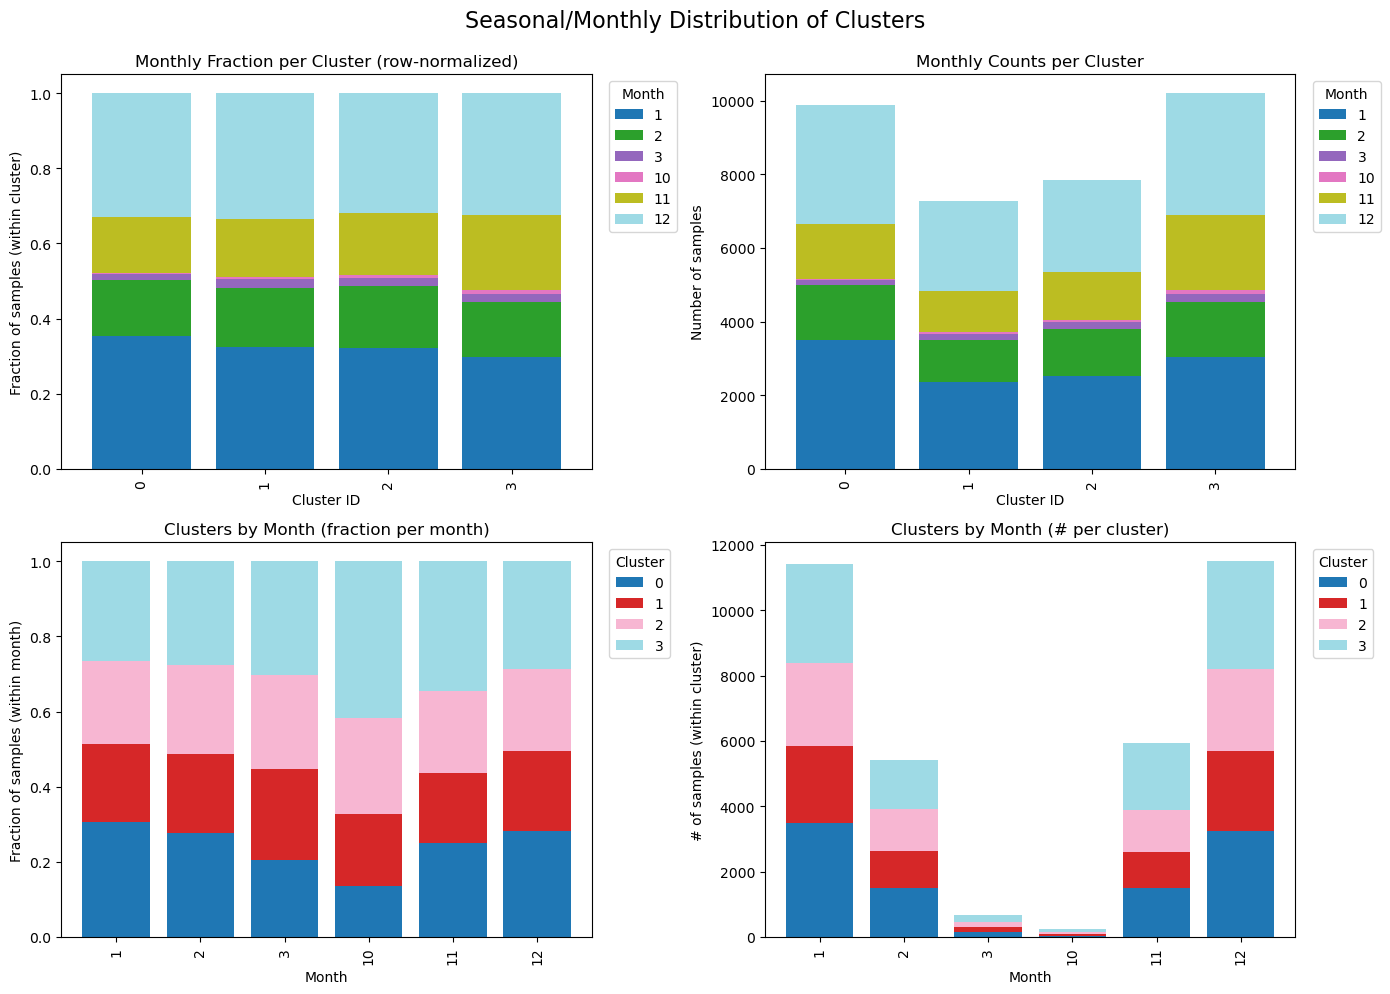

In [28]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# 1) Top‐Left: monthly_frac (clusters on x‐axis, months stacked)
monthly_frac.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="tab20",
    width=0.8
)
axes[0].set_xlabel("Cluster ID")
axes[0].set_ylabel("Fraction of samples (within cluster)")
axes[0].set_title("Monthly Fraction per Cluster (row‐normalized)")
axes[0].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 2) Top‐Right: monthly_counts (clusters on x‐axis, months stacked)
monthly_counts.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    colormap="tab20",
    width=0.8
)
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Number of samples")
axes[1].set_title("Monthly Counts per Cluster")
axes[1].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Right: monthly_frac_within_month.T (months on x‐axis, clusters stacked; fraction within month)
monthly_frac_within_month = monthly_counts.div(monthly_counts.sum(axis=0), axis=1)

monthly_frac_within_month.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    colormap="tab20",
    width=0.8
)
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Fraction of samples (within month)")
axes[2].set_title("Clusters by Month (fraction per month)")
axes[2].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Left: monthly_counts.T (months on x‐axis, clusters stacked; fraction within cluster)
monthly_counts.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[3],
    colormap="tab20",
    width=0.8
)
axes[3].set_xlabel("Month")
axes[3].set_ylabel("# of samples (within cluster)")
axes[3].set_title("Clusters by Month (# per cluster)")
axes[3].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")



# ────────────── D) Adjust layout ──────────────

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle("Seasonal/Monthly Distribution of Clusters", fontsize=16, y=0.99)
plt.show()

----

### Look at distribution for each ESM

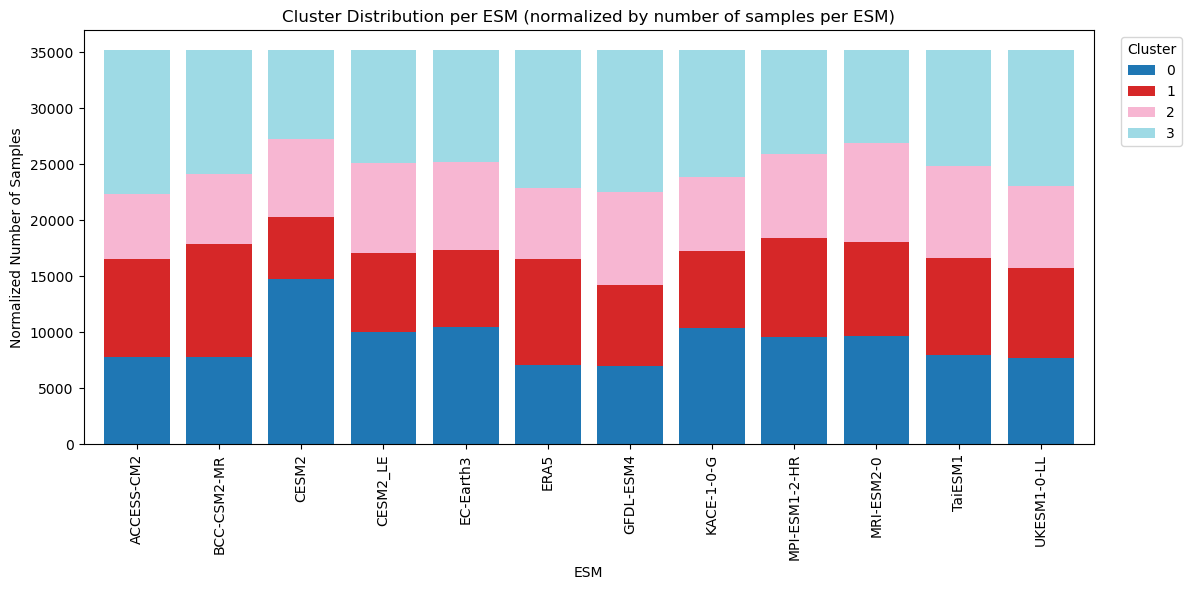

In [29]:
# Make one plot for all ESMs each represented by a stacked barplot normalize by number of samples per ESM
# Calculate the number of samples per ESM
samples_per_esm = df['ESM'].value_counts()
samples_per_esm = samples_per_esm / samples_per_esm.sum()

# Group by ESM and cluster, then count occurrences
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_counts = esm_cluster_counts.div(samples_per_esm, axis=0)
esm_cluster_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20",
    width=0.8
)
plt.xlabel("ESM")
plt.ylabel("Normalized Number of Samples")
plt.title("Cluster Distribution per ESM (normalized by number of samples per ESM)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()